# Joining data

In [ ]:
from IPython.display import display
from pathlib import Path
print(Path.cwd())
# r: raw string
# f: formatted string
import numpy as np
import pandas as pd

file_path = Path(r'C:\Users\xiang\Documents\backup_T580\Videos\Videos\Dropbox\p_jobinterview\coding\pandas_and_plotting')
df1 = pd.read_csv(file_path/'data'/'Chicago_census.csv') # it is already in the directory
display(df1.head(2))

df2 = pd.read_csv(file_path/'data'/'Chicago_wards.csv') # it is already in the directory
display(df2.head(2))

name1 = (pd.DataFrame({'name': ['John', 'George', 'Ringo'],'color': ['Blue', 'Blue', 'Purple']},index=[2, 3, 4]))
name2 = (pd.DataFrame({'name': ['Paul', 'George', 'Ringo'],'carcolor': ['Red', 'Blue', np.nan]},index=[3, 1, 2]))
display('---------')
display(name1)
display(name2)

pet1=(pd.DataFrame({'name': ['fred', 'suzy', 'suzy', 'bob'], 'pet': ['dog', 'dog', 'cat', 'fish']}))
pet2=(pd.DataFrame({'name': ['suzy', 'suzy', 'suzy', 'fred','joe', 'joe'],'color': ['black', 'blue', 'red', 'green', 'yellow', 'blue']}))
display('---------')
display(pet1)
display(pet2)


c:\Users\xiang\Documents\backup_T580\Videos\Videos\Dropbox\p_jobinterview\coding\pandas_and_ploting


,Unnamed: 0,ward,pop_2000,pop_2010,change,address,zip
0,0,NaN,52951,56149,6%,2765 WEST SAINT MARY STREET,60647
1,1,2.0,54361,55805,3%,WM WASTE MANAGEMENT 1500,60622


,Unnamed: 0,ward,alderman,address,zip
0,0,61,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647
1,1,2,Brian Hopkins,1400 NORTH ASHLAND AVENUE,60622


'---------'

,name,color
2,John,Blue
3,George,Blue
4,Ringo,Purple


,name,carcolor
3,Paul,Red
1,George,Blue
2,Ringo,NaN


'---------'

,name,pet
0,fred,dog
1,suzy,dog
2,suzy,cat
3,bob,fish


,name,color
0,suzy,black
1,suzy,blue
2,suzy,red
3,fred,green
4,joe,yellow
5,joe,blue


## inner join

In [14]:
name1.merge(name2, on='name')

,name,color,carcolor
0,George,Blue,Blue
1,Ringo,Purple,NaN


In [ ]:
pet1.merge(pet2, on='name') # inner join one-to-many

,name,pet,color
0,fred,dog,green
1,suzy,dog,black
2,suzy,dog,blue
3,suzy,dog,red
4,suzy,cat,black
5,suzy,cat,blue
6,suzy,cat,red


In [ ]:
# inner join on index
pet1.set_index('name').merge(pet2.set_index('name'), left_index=True, right_index=True) 

,pet,color
name,,
fred,dog,green
suzy,dog,black
suzy,dog,blue
suzy,dog,red
suzy,cat,black
suzy,cat,blue
suzy,cat,red


In [ ]:
pet1.set_index('name').join(pet2.set_index('name'), how='inner')  # join is not often used!!

,pet,color
name,,
fred,dog,green
suzy,dog,black
suzy,dog,blue
suzy,dog,red
suzy,cat,black
suzy,cat,blue
suzy,cat,red


In [4]:
# inner join and rename columns in both tables
df_inner=df1.merge(df2, on='ward', suffixes=('_census', '_ward'))
df_inner.head(2)


,Unnamed: 0_census,ward,pop_2000,pop_2010,change,address_census,zip_census,Unnamed: 0_ward,alderman,address_ward,zip_ward
0,1,2.0,54361,55805,3%,WM WASTE MANAGEMENT 1500,60622,1,Brian Hopkins,1400 NORTH ASHLAND AVENUE,60622
1,2,3.0,40385,53039,31%,17 EAST 38TH STREET,60653,2,Pat Dowell,5046 SOUTH STATE STREET,60609


> many-to-one

In [3]:
# many merged to one
bizonwers = pd.read_csv(file_path/'data'/'licenses.csv')
print(bizonwers.head(2))
print(bizonwers.shape)

df3=df2.merge(bizonwers, on='ward')
biz_count=df3.groupby('ward').agg({'aid':'count'}) # find aid variable and count it
    # same way 
    # biz_count=df3.groupby('ward')['aid'].count()
print(biz_count.sort_values(by=['ward','aid']).head(5))


   Unnamed: 0  account  ward  aid              business              address  \
0           0   307071     3  743  REGGIE'S BAR & GRILL      2105 S STATE ST   
1           1       10    10  829            HONEYBEERS  13200 S HOUSTON AVE   

       zip  
0  60616.0  
1  60633.0  
(10000, 7)
      aid
ward     
2     162
3      90
4     101
5      49
6      62


## left, right, outer, self join

```python
 df0.merge(df1, 
   how='left', 
   left_on='var1', 
   right_on='var2') # this allow self join
```
> merging based on indices is also possible by defult using `.join()`, but it is identical to setting index on in `.merge()`
```python 
 df0.merge(df1, 
   how='left',
   left_on='var1', left_index=True, 
   right_on='var2', right_index=True) # this allow self join
```

In [ ]:
# left, right, outer join and on different id
display(name1.merge(name2, on=['name'], how='left'))

,name,color,carcolor
0,John,Blue,NaN
1,George,Blue,Blue
2,Ringo,Purple,NaN


In [15]:
name1.merge(name2, how='left', left_on=['color'], right_on=['carcolor'],suffixes=('_1', '_2'))

,name_1,color,name_2,carcolor
0,John,Blue,George,Blue
1,George,Blue,George,Blue
2,Ringo,Purple,NaN,NaN


## semi, anti-join

In [5]:
# semi join: 
# finding rows on the left table based on the rows in the right able
df1 = pd.read_csv(file_path/'data'/'movies.csv') # it is already in the directory
print(df1.head(2), df1.shape)

df2 = pd.read_csv(file_path/'data'/'movie_to_genres.csv') # it is already in the directory
print(df2.head(2),df2.shape )

df3=df1.merge(df2, right_on='movie_id', left_on='id', indicator=True) # indicator here similar to stata telling merged or not

# using isin to filter data
df3['id'].isin(df2['movie_id']).head(5)


   Unnamed: 0     id                 title  popularity release_date
0           0    257          Oliver Twist   20.415572   2005-09-23
1           1  14290  Better Luck Tomorrow    3.877036   2002-01-12 (4803, 5)
   Unnamed: 0  movie_id   genre
0           0         5   Crime
1           1         5  Comedy (12160, 3)


0    True
1    True
2    True
3    True
4    True
Name: id, dtype: bool

In [20]:
# find records not shared by both df
pet1.merge(pet2, how='outer', indicator=True).query('_merge != "both"')

,name,pet,color,_merge
0,bob,fish,NaN,left_only
2,joe,NaN,yellow,right_only
3,joe,NaN,blue,right_only


## cross join

In [ ]:
name1.merge(name2, how='cross') # 9 rows because 3*3

,name_x,color,name_y,carcolor
0,John,Blue,Paul,Red
1,John,Blue,George,Blue
2,John,Blue,Ringo,NaN
3,George,Blue,Paul,Red
4,George,Blue,George,Blue
5,George,Blue,Ringo,NaN
6,Ringo,Purple,Paul,Red
7,Ringo,Purple,George,Blue
8,Ringo,Purple,Ringo,NaN


## join indicators
Setting `indicator=True` will include a `_merge` column with values of left_only, right_only, or both

In [19]:
name1.merge(name2, how='left', indicator=True)

,name,color,carcolor,_merge
0,John,Blue,NaN,left_only
1,George,Blue,Blue,both
2,Ringo,Purple,NaN,both


## adding rows

```pd.concat() ``` includes all columns in all columns (by default). ```pd.concat(..., join='inner') ```includes common columns, and  ```.concet(..., sort=True)``` sorts the column names.

* index value is retained
```
pd.concat([df1, df2])
```
* reset index
```
pd.concat([df1, df2], ignore_index=True)
```
* create a multi-level index with the outer index for the two chunks of datasets
```
pd.concat([df1, df2], ignore_index=False, keys=['data1', 'data2'])
```



In [ ]:
display(pd.concat([name1, name2], ignore_index=True)) # reset index
display(pd.concat([name1, name2])) # maintain duplicates of indices

,name,color,carcolor
0,John,Blue,NaN
1,George,Blue,NaN
2,Ringo,Purple,NaN
3,Paul,NaN,Red
4,George,NaN,Blue
5,Ringo,NaN,NaN


,name,color,carcolor
2,John,Blue,NaN
3,George,Blue,NaN
4,Ringo,Purple,NaN
3,Paul,NaN,Red
1,George,NaN,Blue
2,Ringo,NaN,NaN


## adding columns

In [ ]:
display(pd.concat([name1, name2], axis=1)) 
# matching indices and duplicate label of column names

,name,color,name,carcolor
2,John,Blue,Ringo,NaN
3,George,Blue,Paul,Red
4,Ringo,Purple,NaN,NaN
1,NaN,NaN,George,Blue


In [22]:
name2.assign(index_label=name2['name'].str.lower())

,name,carcolor,index_label
3,Paul,Red,paul
1,George,Blue,george
2,Ringo,NaN,ringo


## validate integrity

```pd.concat(..., validate_integrity=True) ``` validates if there are duplicates of index values.

```df_left.merge(df_right,on=..., validate='one-to-many')``` checks the duplicates of rows for **df_left** being 'one' and **df_right** being 'many'.

## (optional) merge_ordered

![merge_ordered](./public/merge_merge_ordered_comparison.png "")

```
pd.merge_ordered(left, right, on=<...>, left_by=<...>, right_by=<...>, fill_method=<...>, suffixes=('_x', '_y'), how='outer')
```

Note that ```on=['country','date']``` is different from ```on=['date', 'country']``` because they differ how NA is filled.



In [ ]:
df1 = pd.DataFrame({
    'date': pd.to_datetime(['2020-01-01','2020-01-03','2020-01-06']),
    'A': [1, 3, 6]
})

df2 = pd.DataFrame({
    'date': pd.to_datetime(['2020-01-02','2020-01-03','2020-01-05']),
    'B': [10, 30, 50]
})

pd.merge_ordered(df1, df2, on='date')

,date,A,B
0,2020-01-01,1.0,NaN
1,2020-01-02,NaN,10.0
2,2020-01-03,3.0,30.0
3,2020-01-05,NaN,50.0
4,2020-01-06,6.0,NaN


In [7]:
# filling values downwards (forward fill)
pd.merge_ordered(df1, df2, on='date', fill_method='ffill')

,date,A,B
0,2020-01-01,1,NaN
1,2020-01-02,1,10.0
2,2020-01-03,3,30.0
3,2020-01-05,3,50.0
4,2020-01-06,6,50.0


## (optional) pd.merge_asof()
Finding the closest matched data from the right table.
    Direction (```direction``` parameter):
* ```backward``` (default): Selects the last row in the right DataFrame whose key is less than or equal to the left key.
* ```forward```: Selects the first row in the right DataFrame whose key is greater than or equal to the left key.
* ```nearest```: Selects the row in the right DataFrame with the closest key.

Note: for time series, ```df['price_diff'] = df['price'].diff()``` calculate the first difference.

Note on using case_when()

C:\Users\xiang\AppData\Local\Temp\ipykernel_30172\7694089.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2019-01-01', periods=24, freq='M')


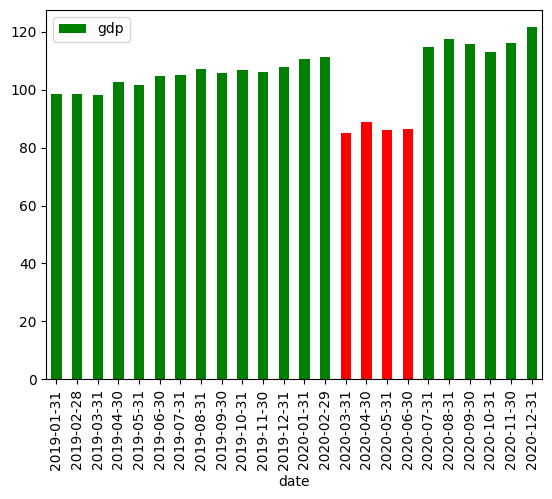

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

dates = pd.date_range('2019-01-01', periods=24, freq='M')
# create a small GDP drop for a recession period (Mar–Jun 2020)
gdp = [100 + i*0.8 + ( -25 if (d.year==2020 and d.month in (3,4,5,6)) else 0) + np.random.randn()*1.5
       for i, d in enumerate(dates)]
econ_status = ['recession' if (d.year==2020 and d.month in (3,4,5,6)) else 'growth' for d in dates]

gdp_recession = pd.DataFrame({'date': dates, 'gdp': gdp, 'econ_status': econ_status})
gdp_recession.head()


# Create a list based on the row value of gdp_recession['econ_status']
is_recession = ['r' if s=='recession' else 'g' for s in gdp_recession['econ_status']]

# refomat date time
gdp_recession['date']=pd.to_datetime(gdp_recession['date']).dt.date

# Plot a bar chart of gdp_recession
gdp_recession.plot(kind='bar', y='gdp', x='date', color=is_recession, rot=90)
plt.show()

